# Multivariate Decision Trees

A univariate tree (CART) tests one feature per node, so its boundary is a staircase of
axis-aligned cuts. A **multivariate** tree tests a linear combination instead:

$$\text{go right if } \; w \cdot x + b > 0$$

where $w$ comes from a linear discriminant fitted on the samples that reach the node
(Alpaydin & Cetin, 1995; Yildiz & Alpaydin, 2001).

This notebook compares three trees on the same data:

| Model | Split | Trained by |
|---|---|---|
| `DecisionTreeClassifier` | one feature, hard | greedy impurity search |
| `MultivariateDecisionTree` | linear combination, hard | discriminant per node |
| `SoftDecisionTree` | linear combination, soft | backpropagation |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from neural_trees import MultivariateDecisionTree, SoftDecisionTree

## 1. Where the oblique split pays off

A rotated boundary is the textbook case: one hyperplane against a staircase.

In [2]:
rng = np.random.RandomState(0)
X_toy = rng.randn(400, 2)
y_toy = (X_toy[:, 0] + X_toy[:, 1] > 0).astype(int)

models = {
    "CART (depth 2)": DecisionTreeClassifier(max_depth=2, random_state=0),
    "Multivariate (depth 2)": MultivariateDecisionTree(max_depth=2, random_state=0),
    "Soft (depth 2)": SoftDecisionTree(depth=2, max_epochs=60, random_state=0),
}

for name, model in models.items():
    scores = cross_val_score(model, X_toy, y_toy, cv=5)
    print(f"{name:<24} {scores.mean():.3f} +/- {scores.std():.3f}")

CART (depth 2)           0.893 +/- 0.032
Multivariate (depth 2)   0.995 +/- 0.006


Soft (depth 2)           0.997 +/- 0.005


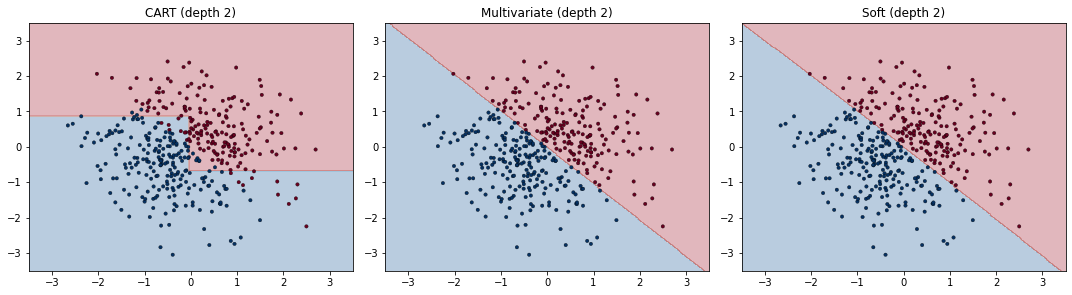

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 300), np.linspace(-3.5, 3.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_toy, y_toy)
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="RdBu_r")
    ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, cmap="RdBu_r", s=12, edgecolors="k", linewidths=0.3)
    ax.set_title(name)
plt.tight_layout()
plt.show()

CART needs depth after depth of steps to approximate the diagonal. One discriminant node gets it exactly.

## 2. Real datasets

5-fold cross-validation with `StandardScaler`.

In [4]:
def bench(X, y, label):
    rows = {
        "CART": DecisionTreeClassifier(max_depth=3, random_state=0),
        "Multivariate": MultivariateDecisionTree(max_depth=3, random_state=0),
        "Soft": SoftDecisionTree(depth=3, max_epochs=60, random_state=0),
    }
    print(f"--- {label} ---")
    for name, model in rows.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        scores = cross_val_score(pipe, X, y, cv=5)
        print(f"{name:<14} {scores.mean():.3f} +/- {scores.std():.3f}")

bench(*load_wine(return_X_y=True), "Wine")
bench(*load_breast_cancer(return_X_y=True), "Breast Cancer")

--- Wine ---
CART           0.893 +/- 0.066


Multivariate   0.939 +/- 0.037


Soft           0.955 +/- 0.028
--- Breast Cancer ---
CART           0.917 +/- 0.022
Multivariate   0.951 +/- 0.032


Soft           0.977 +/- 0.012


## 3. Reading a split

Every internal node exposes its hyperplane, so a split stays interpretable: it is a weighted sum of features, not a black box.

In [5]:
X, y = load_wine(return_X_y=True)
feature_names = load_wine().feature_names

scaler = StandardScaler().fit(X)
mdt = MultivariateDecisionTree(max_depth=3, random_state=0).fit(scaler.transform(X), y)
print(f"internal nodes: {mdt.n_nodes_}, depth reached: {mdt.tree_depth_}")

w, b = mdt.get_split_weights()[0]
order = np.argsort(-np.abs(w))[:5]
print("\nroot split, top 5 features by |weight|:")
for i in order:
    print(f"  {feature_names[i]:<30} {w[i]:+.3f}")
print(f"  bias {b:+.3f}")

internal nodes: 2, depth reached: 2

root split, top 5 features by |weight|:
  flavanoids                     -9.803
  color_intensity                +6.063
  od280/od315_of_diluted_wines   -3.877
  hue                            -2.122
  malic_acid                     +2.092
  bias -9.405


## Takeaway

- Multivariate splits win when classes are separated by a **correlated combination** of features, and buy that with a denser model per node.
- Soft trees relax the same linear split into a probabilistic gate and train it end to end.
- CART stays the better choice when the true boundary really is axis-aligned, or when a single-feature rule is required for auditability.

**References**

- Alpaydin, E., & Cetin, U. (1995). Multivariate Statistical Techniques for Constructive Induction.
- Yildiz, O. T., & Alpaydin, E. (2001). Omnivariate Decision Trees. *IEEE TNN*, 12(6), 1539-1546.
- Irsoy, O., Yildiz, O. T., & Alpaydin, E. (2012). Soft Decision Trees. *ICPR*.